In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import CIFAR10
import matplotlib.pyplot as plt
import torchvision.models as models

In [2]:
from pathlib import Path

data_dir = Path("/workspaces/DSC140B-CODING-HW/data/data")
image_paths = sorted(data_dir.glob("*.jpg"))

print("Number of images:", len(image_paths))
print(image_paths[:5])

Number of images: 9181
[PosixPath('/workspaces/DSC140B-CODING-HW/data/data/Anaheim-0021450d.jpg'), PosixPath('/workspaces/DSC140B-CODING-HW/data/data/Anaheim-00380032.jpg'), PosixPath('/workspaces/DSC140B-CODING-HW/data/data/Anaheim-00752b22.jpg'), PosixPath('/workspaces/DSC140B-CODING-HW/data/data/Anaheim-011a4d5d.jpg'), PosixPath('/workspaces/DSC140B-CODING-HW/data/data/Anaheim-01704105.jpg')]


In [3]:
labels_str = [p.stem.split("-")[0] for p in image_paths]

print(labels_str[:10])
print(sorted(set(labels_str)))

['Anaheim', 'Anaheim', 'Anaheim', 'Anaheim', 'Anaheim', 'Anaheim', 'Anaheim', 'Anaheim', 'Anaheim', 'Anaheim']
['Anaheim', 'Bakersfield', 'Los_Angeles', 'Riverside', 'SLO', 'San_Diego']


## RestNet18

In [4]:
# load ResNet-18
ft_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

In [5]:
# freeze everything
for param in ft_model.parameters():
    param.requires_grad = False

# unfreeze the last convolutional block for learning features
for param in ft_model.layer4.parameters():
    param.requires_grad = True

In [6]:
# execuation location
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [7]:
# replace the final layer with 6-class classifier for proj requirement. Quit the frozen final layer directly
ft_model.fc = nn.Linear(512, 6)
ft_model = ft_model.to(device)

In [8]:
# choose the loss function
ft_loss_fn = nn.CrossEntropyLoss()

# choose optimizer
ft_optimizer = torch.optim.Adam([
    {'params': ft_model.layer4.parameters(), 'lr': 1e-4},
    {'params': ft_model.fc.parameters(),     'lr': 1e-3},
])

In [9]:
# split the data
from sklearn.model_selection import train_test_split

train_paths, val_paths = train_test_split(
    image_paths,
    test_size=0.2,
    random_state=42,
    stratify=labels_str
)

print(len(train_paths), len(val_paths))

7344 1837


In [10]:
# build label mapping
classes = sorted(set(labels_str))
class_to_idx = {c: i for i, c in enumerate(classes)}

print(classes)
print(class_to_idx)

['Anaheim', 'Bakersfield', 'Los_Angeles', 'Riverside', 'SLO', 'San_Diego']
{'Anaheim': 0, 'Bakersfield': 1, 'Los_Angeles': 2, 'Riverside': 3, 'SLO': 4, 'San_Diego': 5}


In [11]:
# define transforms
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [12]:
# define the dataset
from PIL import Image
from torch.utils.data import Dataset

class SoCalDataset(Dataset):
    def __init__(self, paths, transform=None):
        self.paths = paths
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        image = Image.open(path).convert("RGB")

        label_str = path.stem.split("-")[0]
        label = class_to_idx[label_str]

        if self.transform:
            image = self.transform(image)

        return image, label

In [13]:
def evaluate(model, loader):
    model.eval()
    correct, n = 0, 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model(X_batch)
            correct += (pred.argmax(dim=1) == y_batch).sum().item()
            n += len(y_batch)

    return correct / n

In [14]:
# create train_loader and val_loader
from torch.utils.data import DataLoader

train_dataset = SoCalDataset(train_paths, transform=train_transform)
val_dataset = SoCalDataset(val_paths, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

X, y = next(iter(train_loader))
print(X.shape)
print(y.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [15]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# store losses
train_iter_losses = []   # for iteration vs empirical risk
train_epoch_losses = []  # average train loss per epoch
val_epoch_losses = []    # average validation loss per epoch

num_epochs = 8

for epoch in range(num_epochs):
    # -------------------
    # training
    # -------------------
    ft_model.train()
    running_loss = 0.0
    correct = 0
    n = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        ft_optimizer.zero_grad()
        logits = ft_model(X_batch)
        loss = ft_loss_fn(logits, y_batch)
        loss.backward()
        ft_optimizer.step()

        # loss for this iteration (mini-batch)
        train_iter_losses.append(loss.item())

        batch_size = X_batch.size(0)
        running_loss += loss.item() * batch_size
        correct += (logits.argmax(dim=1) == y_batch).sum().item()
        n += batch_size

    train_epoch_loss = running_loss / n
    train_acc = correct / n
    train_epoch_losses.append(train_epoch_loss)

    # -------------------
    # validation
    # -------------------
    ft_model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_n = 0

    with torch.no_grad():
        for X_val, y_val in val_loader:
            X_val = X_val.to(device)
            y_val = y_val.to(device)

            val_logits = ft_model(X_val)
            val_loss = ft_loss_fn(val_logits, y_val)

            batch_size = X_val.size(0)
            val_running_loss += val_loss.item() * batch_size
            val_correct += (val_logits.argmax(dim=1) == y_val).sum().item()
            val_n += batch_size

    val_epoch_loss = val_running_loss / val_n
    val_acc = val_correct / val_n
    val_epoch_losses.append(val_epoch_loss)

    print(f"Epoch {epoch+1}/{num_epochs} "
          f"train_loss={train_epoch_loss:.4f} "
          f"train_acc={train_acc:.3f} "
          f"val_loss={val_epoch_loss:.4f} "
          f"val_acc={val_acc:.3f}")

Epoch 1/8 train_loss=0.6510 train_acc=0.766 val_loss=0.4272 val_acc=0.850


Epoch 2/8 train_loss=0.3345 train_acc=0.883 val_loss=0.4591 val_acc=0.843
Epoch 3/8 train_loss=0.2208 train_acc=0.921 val_loss=0.3729 val_acc=0.882
Epoch 4/8 train_loss=0.1686 train_acc=0.943 val_loss=0.3951 val_acc=0.879
Epoch 5/8 train_loss=0.1377 train_acc=0.950 val_loss=0.3906 val_acc=0.889
Epoch 6/8 train_loss=0.1009 train_acc=0.966 val_loss=0.3733 val_acc=0.906
Epoch 7/8 train_loss=0.0908 train_acc=0.968 val_loss=0.3866 val_acc=0.906
Epoch 8/8 train_loss=0.0649 train_acc=0.977 val_loss=0.4037 val_acc=0.905


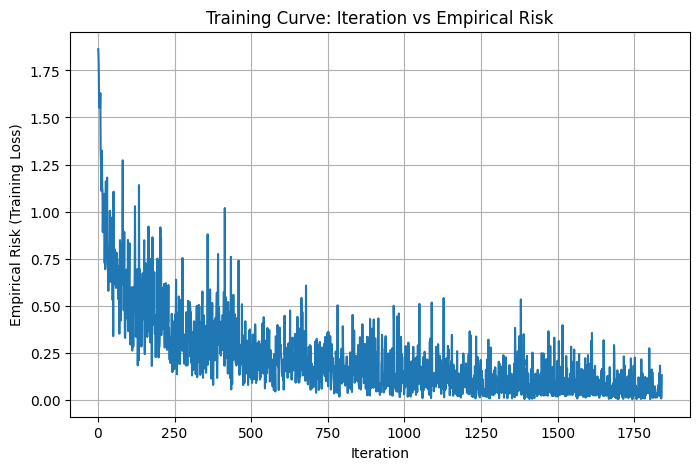

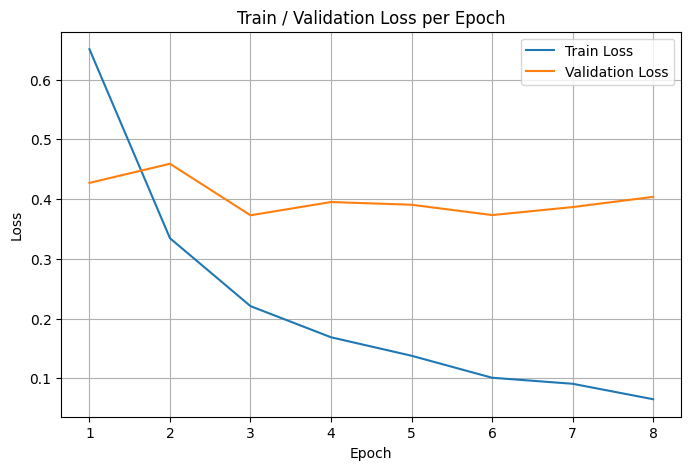

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# 1) iteration number vs empirical risk
plt.figure(figsize=(8,5))
plt.plot(np.arange(1, len(train_iter_losses)+1), train_iter_losses)
plt.xlabel("Iteration")
plt.ylabel("Empirical Risk (Training Loss)")
plt.title("Training Curve: Iteration vs Empirical Risk")
plt.grid(True)
plt.show()

# 2) epoch loss curve
plt.figure(figsize=(8,5))
plt.plot(np.arange(1, len(train_epoch_losses)+1), train_epoch_losses, label="Train Loss")
plt.plot(np.arange(1, len(val_epoch_losses)+1), val_epoch_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train / Validation Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()